In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
beneficiary = pd.read_csv('Train_Beneficiarydata.csv')
inpatient = pd.read_csv('Train_Inpatientdata.csv')
outpatient = pd.read_csv('Train_Outpatientdata.csv')
labels = pd.read_csv('Train_data.csv')

In [7]:
# Check shape
print(beneficiary.shape)
print(inpatient.shape)
print(outpatient.shape)
print(labels.shape)


(138556, 25)
(40474, 30)
(517737, 27)
(5410, 2)


In [8]:
# Check first 5 rows
print(beneficiary.head())
print(inpatient.head())


      BeneID         DOB  DOD  Gender  Race RenalDiseaseIndicator  State  \
0  BENE11001  1943-01-01  NaN       1     1                     0     39   
1  BENE11002  1936-09-01  NaN       2     1                     0     39   
2  BENE11003  1936-08-01  NaN       1     1                     0     52   
3  BENE11004  1922-07-01  NaN       1     1                     0     39   
4  BENE11005  1935-09-01  NaN       1     1                     0     24   

   County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ...  \
0     230                   12                   12  ...   
1     280                   12                   12  ...   
2     590                   12                   12  ...   
3     270                   12                   12  ...   
4     680                   12                   12  ...   

   ChronicCond_Depression  ChronicCond_Diabetes  ChronicCond_IschemicHeart  \
0                       1                     1                          1   
1                       2 

In [9]:
# Check missing values
print(beneficiary.isnull().sum())
print(inpatient.isnull().sum())
print(outpatient.isnull().sum())

BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                      0
IPAnnualReimbursementAmt                0
IPAnnualDeductibleAmt                   0
OPAnnualReimbursementAmt          

In [10]:
print(beneficiary.head(10))
print(inpatient.head(10))


      BeneID         DOB         DOD  Gender  Race RenalDiseaseIndicator  \
0  BENE11001  1943-01-01         NaN       1     1                     0   
1  BENE11002  1936-09-01         NaN       2     1                     0   
2  BENE11003  1936-08-01         NaN       1     1                     0   
3  BENE11004  1922-07-01         NaN       1     1                     0   
4  BENE11005  1935-09-01         NaN       1     1                     0   
5  BENE11006  1976-09-01         NaN       2     1                     0   
6  BENE11007  1940-09-01  2009-12-01       1     2                     0   
7  BENE11008  1934-02-01         NaN       2     1                     0   
8  BENE11009  1929-06-01         NaN       1     1                     Y   
9  BENE11010  1936-07-01         NaN       2     1                     0   

   State  County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ...  \
0     39     230                   12                   12  ...   
1     39     280             

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64


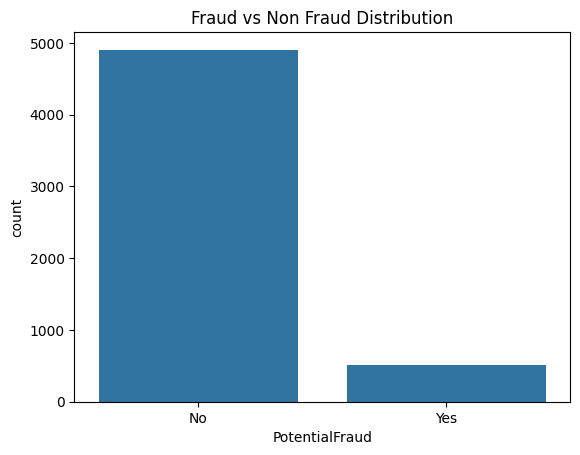

In [11]:
print(labels['PotentialFraud'].value_counts())

sns.countplot(x='PotentialFraud', data=labels)
plt.title('Fraud vs Non Fraud Distribution')
plt.show()

In [12]:
claims = pd.concat([inpatient, outpatient], ignore_index=True)
claims = claims.merge(beneficiary, on='BeneID', how='left')
claims = claims.merge(labels, on='Provider', how='left')

print(claims.shape)
print(claims.head())

(558211, 55)
      BeneID   ClaimID ClaimStartDt  ClaimEndDt  Provider  \
0  BENE11001  CLM46614   2009-04-12  2009-04-18  PRV55912   
1  BENE11001  CLM66048   2009-08-31  2009-09-02  PRV55907   
2  BENE11001  CLM68358   2009-09-17  2009-09-20  PRV56046   
3  BENE11011  CLM38412   2009-02-14  2009-02-22  PRV52405   
4  BENE11014  CLM63689   2009-08-13  2009-08-30  PRV56614   

   InscClaimAmtReimbursed AttendingPhysician OperatingPhysician  \
0                   26000          PHY390922                NaN   
1                    5000          PHY318495          PHY318495   
2                    5000          PHY372395                NaN   
3                    5000          PHY369659          PHY392961   
4                   10000          PHY379376          PHY398258   

  OtherPhysician AdmissionDt  ... ChronicCond_Diabetes  \
0            NaN  2009-04-12  ...                    1   
1            NaN  2009-08-31  ...                    1   
2      PHY324689  2009-09-17  ...          

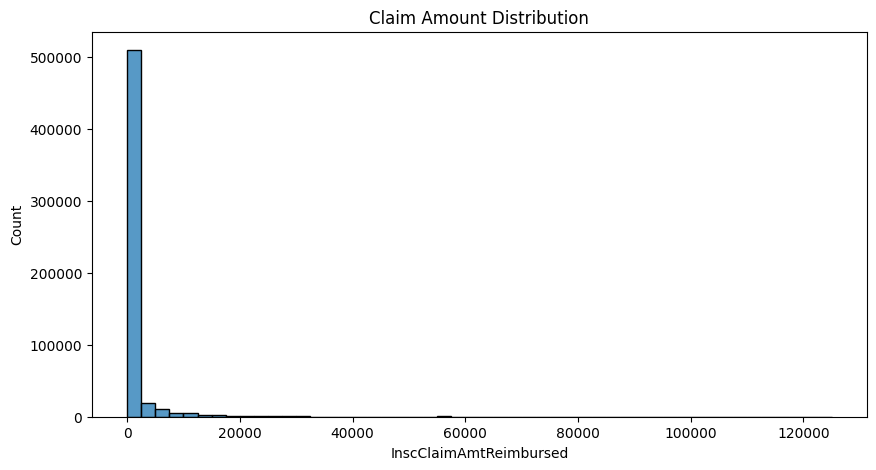

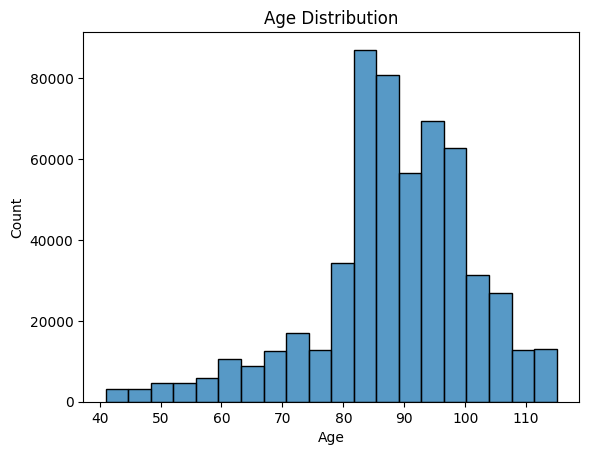

In [13]:
# Claim amount distribution
plt.figure(figsize=(10,5))
sns.histplot(claims['InscClaimAmtReimbursed'], bins=50)
plt.title('Claim Amount Distribution')
plt.show()

# Age distribution
claims['Age'] = 2024 - pd.to_datetime(claims['DOB']).dt.year
sns.histplot(claims['Age'], bins=20)
plt.title('Age Distribution')
plt.show()

In [14]:
claims.to_csv('merged_data.csv', index=False)
print("Dataset saved successfully!")

Dataset saved successfully!


In [15]:
# Check data types
print(beneficiary.dtypes)
print(inpatient.dtypes)
print(outpatient.dtypes)

BeneID                               str
DOB                                  str
DOD                                  str
Gender                             int64
Race                               int64
RenalDiseaseIndicator                str
State                              int64
County                             int64
NoOfMonths_PartACov                int64
NoOfMonths_PartBCov                int64
ChronicCond_Alzheimer              int64
ChronicCond_Heartfailure           int64
ChronicCond_KidneyDisease          int64
ChronicCond_Cancer                 int64
ChronicCond_ObstrPulmonary         int64
ChronicCond_Depression             int64
ChronicCond_Diabetes               int64
ChronicCond_IschemicHeart          int64
ChronicCond_Osteoporasis           int64
ChronicCond_rheumatoidarthritis    int64
ChronicCond_stroke                 int64
IPAnnualReimbursementAmt           int64
IPAnnualDeductibleAmt              int64
OPAnnualReimbursementAmt           int64
OPAnnualDeductib

In [16]:
# Check data types
print(beneficiary.dtypes)
print(inpatient.dtypes)
print(outpatient.dtypes)

BeneID                               str
DOB                                  str
DOD                                  str
Gender                             int64
Race                               int64
RenalDiseaseIndicator                str
State                              int64
County                             int64
NoOfMonths_PartACov                int64
NoOfMonths_PartBCov                int64
ChronicCond_Alzheimer              int64
ChronicCond_Heartfailure           int64
ChronicCond_KidneyDisease          int64
ChronicCond_Cancer                 int64
ChronicCond_ObstrPulmonary         int64
ChronicCond_Depression             int64
ChronicCond_Diabetes               int64
ChronicCond_IschemicHeart          int64
ChronicCond_Osteoporasis           int64
ChronicCond_rheumatoidarthritis    int64
ChronicCond_stroke                 int64
IPAnnualReimbursementAmt           int64
IPAnnualDeductibleAmt              int64
OPAnnualReimbursementAmt           int64
OPAnnualDeductib

In [17]:
print(beneficiary.dtypes)
print(inpatient.dtypes)
print(outpatient.dtypes)

BeneID                               str
DOB                                  str
DOD                                  str
Gender                             int64
Race                               int64
RenalDiseaseIndicator                str
State                              int64
County                             int64
NoOfMonths_PartACov                int64
NoOfMonths_PartBCov                int64
ChronicCond_Alzheimer              int64
ChronicCond_Heartfailure           int64
ChronicCond_KidneyDisease          int64
ChronicCond_Cancer                 int64
ChronicCond_ObstrPulmonary         int64
ChronicCond_Depression             int64
ChronicCond_Diabetes               int64
ChronicCond_IschemicHeart          int64
ChronicCond_Osteoporasis           int64
ChronicCond_rheumatoidarthritis    int64
ChronicCond_stroke                 int64
IPAnnualReimbursementAmt           int64
IPAnnualDeductibleAmt              int64
OPAnnualReimbursementAmt           int64
OPAnnualDeductib

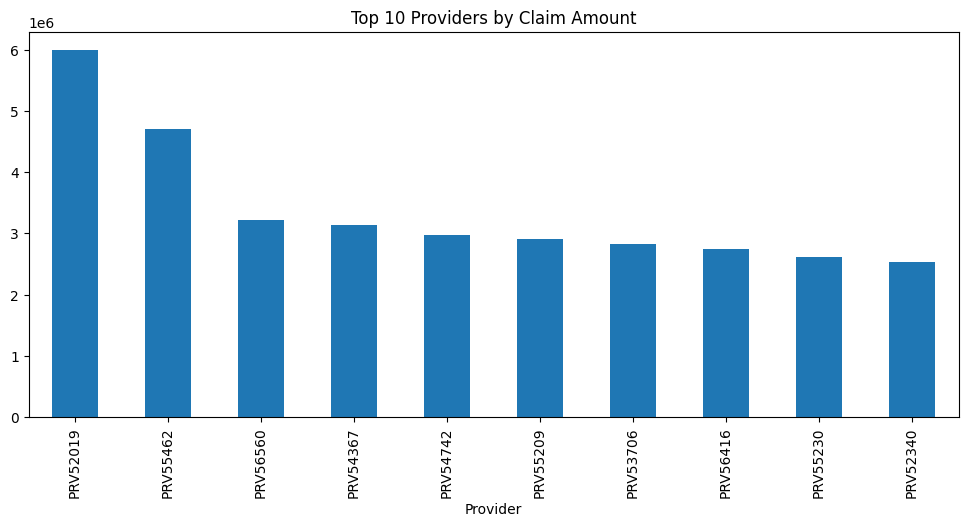

In [18]:
# Top 10 providers by claim count
top_providers = claims.groupby('Provider')['InscClaimAmtReimbursed'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
top_providers.plot(kind='bar')
plt.title('Top 10 Providers by Claim Amount')
plt.show()

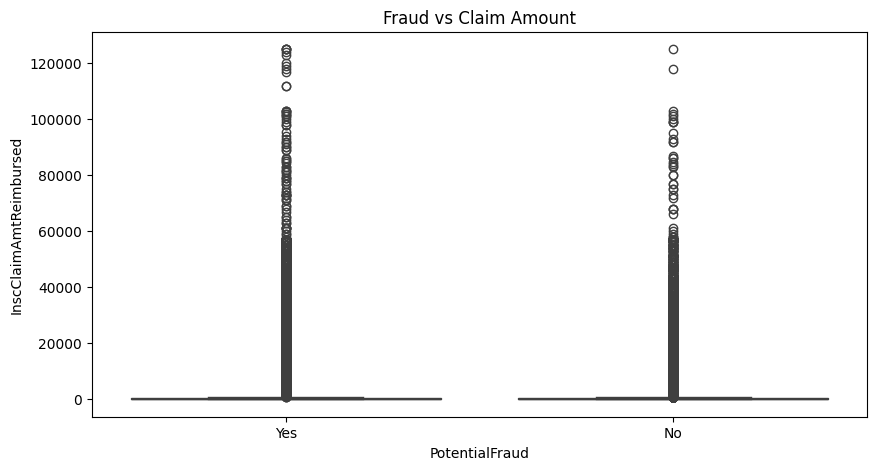

In [19]:
# Fraud vs claim amount
plt.figure(figsize=(10,5))
sns.boxplot(x='PotentialFraud', y='InscClaimAmtReimbursed', data=claims)
plt.title('Fraud vs Claim Amount')
plt.show()